This example uses the fluid injection implementation of Pierre Romanet to solve the SEAS Benchmark Problem 6. See `/examples/scec_benchmarks/BP6/SEAS_BP6.pdf` for an extensive description of the problem statement.

In [1]:
%matplotlib widget

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from qdyn import qdyn

In [ ]:
# Instantiate the QDYN class object
p = qdyn()

# Set up size of the fault
ds = 10 # Discretisation size
N = 2**12 # Number of elements
N_half = N // 2
L = ds * N # Size of the fault

# Set up initial theta
theta_ini = 4e-3 / 1e-6 * np.exp(
    7.0 / 5.0 * np.log(2.0 * 1e-6 / 1e-12 * np.sinh(29.2e6 / (0.007 * 50e6))) - 0.6 / 0.005
)

# General simulation parameters
set_dict = {
    "FRICTION_MODEL": "RSF", # Rate and state friction
    "MESHDIM": 1, # 1D antiplane fault in 2D medium
    "FINITE": 1, # Make it a finite fault loaded by constant velocity on the side
    "SOLVER": 2, # Runge-Kutta-Fehlberg solver
    "V_PL": 0.0, # The fault is block on some part
    "L": L, # Length of the fault 
    "SIGMA": 50.0e6,# Normal traction along the fault
    "VS": 3464.0, # Shear Velocity
    "MU": 32.04e9, # Shear modulus
    "FEAT_VAR_K": 0, # Coupling permeability
    "FEAT_FLUID_DIFF": 1, # Allowing for fault diffusion
    "FEAT_LOCALISATION": 0,
    "ACC": 1e-7, # Accuracy of the time solver
    "N": N, # Number of the elements (must be a power of 2)
    "NSTOP": 0, # Stop at t= TMAX
    "TMAX": 2 * 365.25 * 86400 # Finish time of the simulation
}
   
# RSF parameters
set_dict_RSF = {
    "RNS_LAW": 0,
    "THETA_LAW": 1, # Aging law
    "A": 0.007,
    "B": 0.005,
    "DC": 0.004,
    "MU_SS": 0.6,
    "V_SS": 1e-6,
    "V_0":1e-12,
    "TH_0": theta_ini, # Initial state,
}

 # Fluid diffusion model 
set_dict_fluid_diff = {
     "RHOF": 1e3,						# Density Fluid
     "BETA": 1e-8,						# Bulk compressibility (fluid + pore) [1/Pa]
     "ETA": 1e-3,						# Fluid dynamic viscosity [Pa s]
     "PHI": 0.1,                       # Porosity 
     "PERMEABILITY": 1e-13,            # Permeability
     "nb_source": 1,                   # Number of source (only one for now)
     "rate_injection":  [1.25e-6],       # Injection rate (m/s)
     "index_injection": [N_half],          # Index of the fault where injection is performed (for FORTRAN NOT PYTHON)
     "t_injection_beg": [0.0],           # Beginning time of injection
     "t_injection_end": [100.0 * 86400.0],  # End time of injection
     "P_a": 0.0
}
 
 # Variable permeability
set_dict_var_k = {
    "Lk": 1.0,
    "Tk": 1000,
    "kmin": 1e-15,      
    "kmax": 1e-13,
    "Snk": 1e6,
}

# Merge dictionnaries
set_dict["SET_DICT_RSF"] = set_dict_RSF
set_dict["SET_DICT_FLUID_DIFF"] = set_dict_fluid_diff
set_dict["SET_DICT_VAR_K"] = set_dict_var_k
set_dict["NTOUT_OX"] = 10        # Save output every N steps

# Set the simulation
p.settings(set_dict)

# Make the mesh
p.render_mesh()

# Write input
p.write_input()

True

In [ ]:
# This should finish in 5-10 minutes. The total output size will be ~2.3 GB
p.run()

True

In [ ]:
# Read output (takes ~1 minute)
p.read_output()

x_unique = p.ox["x"].unique()
sort_inds = np.argsort(x_unique)
x_unique = x_unique[sort_inds]
t_vals = np.sort(p.ox["t"].unique())
v = p.ox["v"]
v = np.reshape(v, (len(t_vals), len(x_unique)))
theta = np.reshape(p.ox["theta"], (len(t_vals), len(x_unique)))
P = np.reshape(p.ox["P"], (len(t_vals), len(x_unique)))

Text(0.5, 1.0, 'Slip velocity at injection point')

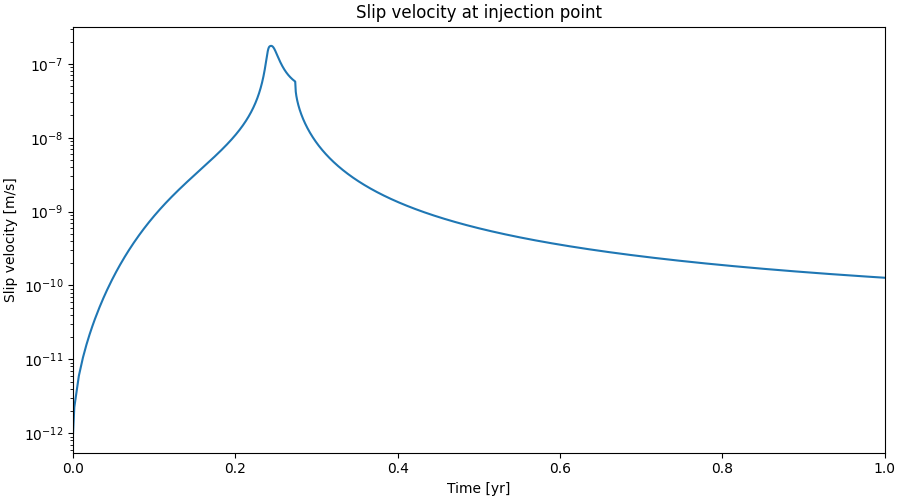

In [13]:
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.semilogy(t_vals / (86400 * 365.25), v[:, np.int16(N_half - 1)])
ax.set_xlim((0, 1))
ax.set_xlabel("Time [yr]")
ax.set_ylabel("Slip velocity [m/s]")
ax.set_title("Slip velocity at injection point")

Text(0.5, 1.0, 'Pressure at injection point')

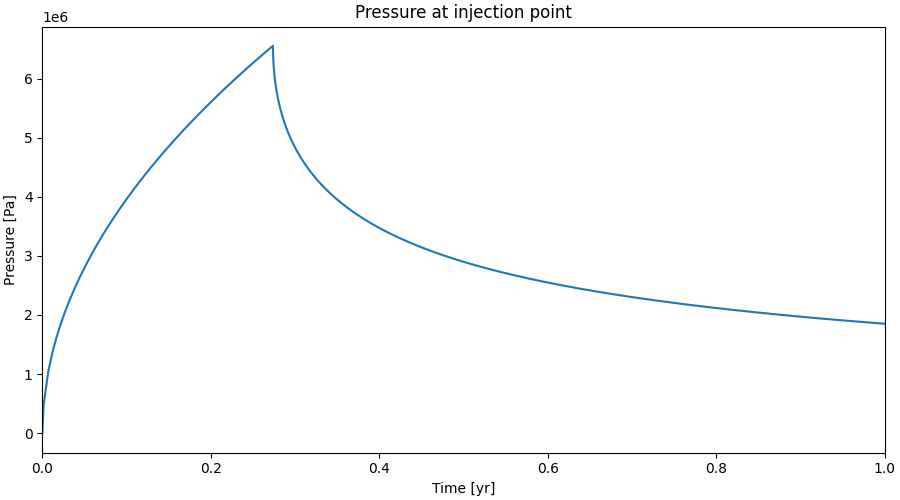

In [14]:
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(t_vals / (86400 * 365.25), P[:, np.int16(N_half - 1)])
ax.set_xlim((0, 1))
ax.set_xlabel("Time [yr]")
ax.set_ylabel("Pressure [Pa]")
ax.set_title("Pressure at injection point")